# IMPORT

In [1]:
import pandas as pd
import time
from scipy.sparse import csr_matrix, vstack
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.base import clone
from sklearn.decomposition import TruncatedSVD
import umap

/home/apkin/school21/projects/ML6_Unsupervised_learning_ID_1254805-1/src/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# LOAD DATA AND PREPROCESSING

load data from [kaggle]("https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset")

In [2]:
rating = pd.read_csv("./data/Ratings.csv")
users = pd.read_csv("./data/Users.csv")

In [3]:
rating.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [4]:
rating.info()

<class 'pandas.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   User-ID      1149780 non-null  int64
 1   ISBN         1149780 non-null  str  
 2   Book-Rating  1149780 non-null  int64
dtypes: int64(2), str(1)
memory usage: 26.3 MB


### Create the sparse matrix

In [5]:
user_indices, user_ids =  pd.factorize(rating['User-ID'])
book_indices, book_ids = pd.factorize(rating['ISBN'])

In [6]:
user_book = csr_matrix(
    (
        rating['Book-Rating'],
        (user_indices, book_indices)
    )
)

In [7]:
user_book.shape

(105283, 340556)

### Create the target column

In [8]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [9]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  str    
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 6.4 MB


In [10]:
users_age = users.set_index("User-ID")['Age']
y = users_age.reindex(user_ids).reset_index(drop=True)
y

0          NaN
1          NaN
2         16.0
3         16.0
4         37.0
          ... 
105278     NaN
105279    18.0
105280    38.0
105281    14.0
105282    12.0
Name: Age, Length: 105283, dtype: float64

### Split the dataset into training, valid, and test parts

In [11]:
mask = y.notna()
X = user_book[mask.to_numpy()]
y = y[mask]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=2/3,
    random_state=21
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=21
)

### Look at the distribution of data by age

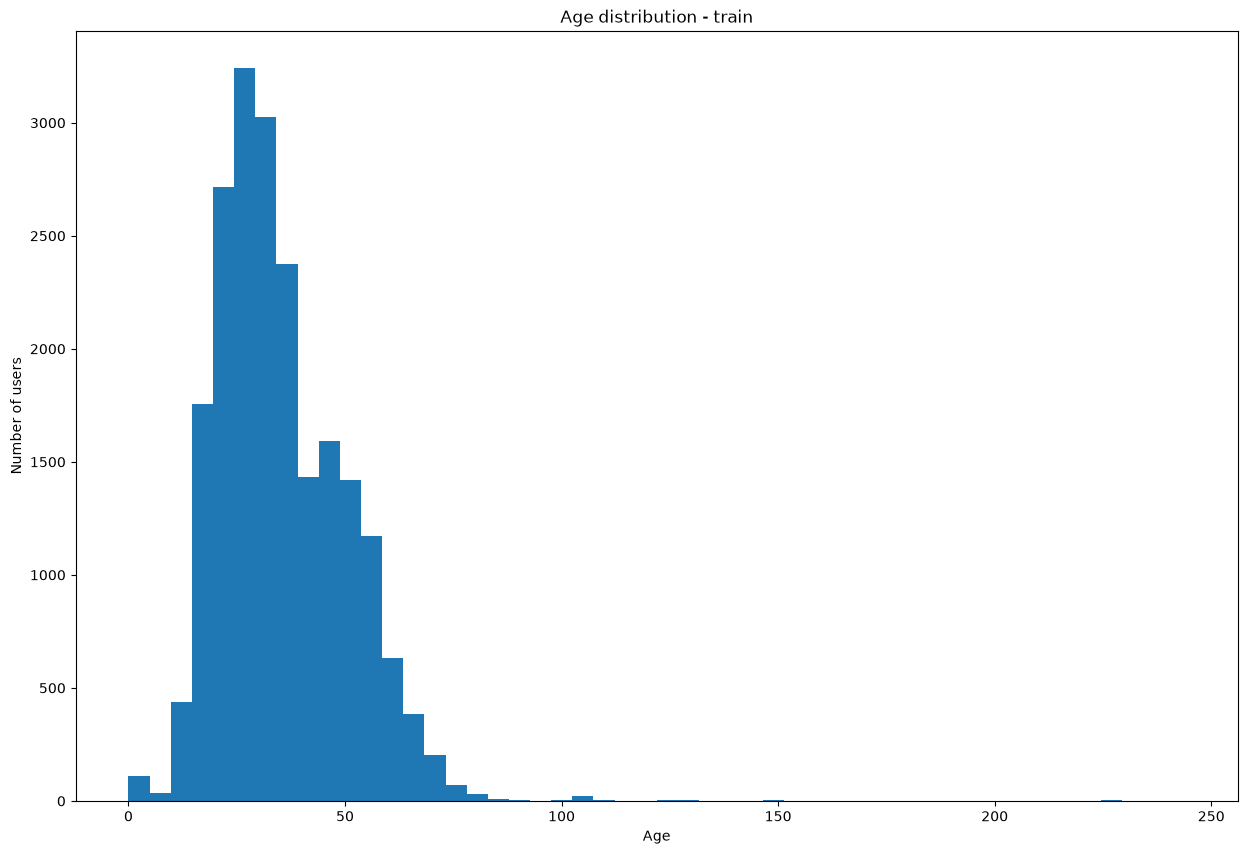

In [12]:
plt.figure(figsize=(15,10))

plt.hist(y_train, bins=50)
plt.xlabel("Age")
plt.ylabel("Number of users")
plt.title("Age distribution - train")

plt.show()

In [13]:
y_train.describe()

count    20702.000000
mean        35.389334
std         14.852319
min          0.000000
25%         25.000000
50%         33.000000
75%         45.000000
max        244.000000
Name: Age, dtype: float64

### Domain-based validation of the target

In [14]:
train_mask = y_train.between(10, 90)
valid_mask = y_valid.between(10, 90)
test_mask = y_test.between(10, 90)

X_train = X_train[train_mask.to_numpy()]
y_train = y_train[train_mask]

X_valid = X_valid[valid_mask.to_numpy()]
y_valid = y_valid[valid_mask]

X_test = X_test[test_mask.to_numpy()]
y_test = y_test[test_mask]

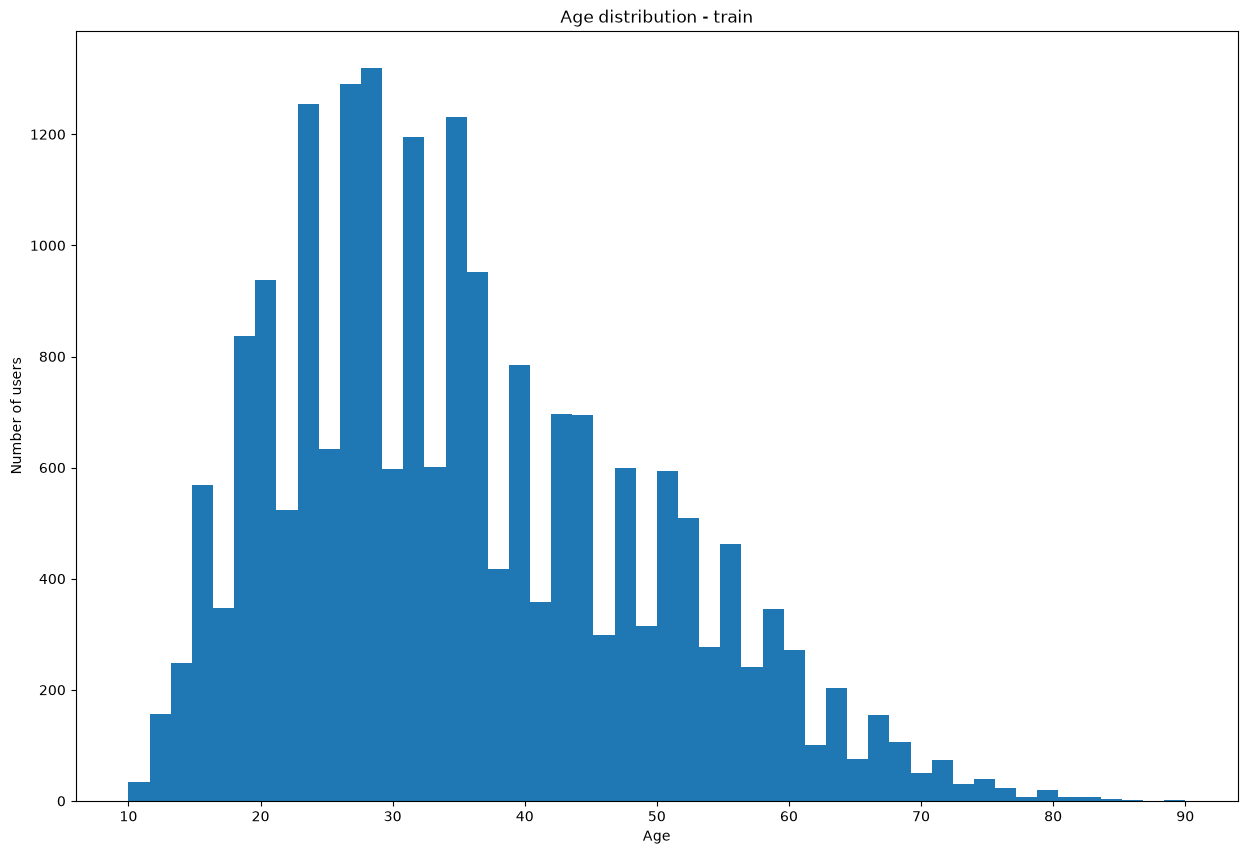

In [15]:
plt.figure(figsize=(15,10))

plt.hist(y_train, bins=50)
plt.xlabel("Age")
plt.ylabel("Number of users")
plt.title("Age distribution - train")

plt.show()

# Build linear and random forest models to predict user age based on user-book interactions.


create resulting table

In [16]:
table = pd.DataFrame(
    columns=[
        'model_name',
        'best_params',
        'MAE_train',
        'MAE_valid',
        'R2_train',
        'R2_valid',
        'fit_time_sec'
    ]
)

models = {}

Function for model training

In [17]:
def estimate(model, model_name, params, X_train, X_valid, y_train, y_valid, n_iter=50):
    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=21
    )

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=n_iter,
        scoring='neg_mean_absolute_error',
        cv=cv,
        random_state=21,
        n_jobs=-1,
        refit=False
    )

    search.fit(X_train, y_train)

    best_params = search.best_params_

    best_model = clone(model).set_params(**best_params)

    start = time.perf_counter()

    best_model.fit(X_train, y_train)

    fit_time = time.perf_counter() - start

    y_pred_train = best_model.predict(X_train)
    y_pred_valid = best_model.predict(X_valid)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_valid = mean_absolute_error(y_valid, y_pred_valid)

    r2_train = r2_score(y_train, y_pred_train)
    r2_valid = r2_score(y_valid, y_pred_valid)

    result = {
        'model_name' : model_name,
        'best_params' : best_params,
        'MAE_train' : mae_train,
        'MAE_valid' : mae_valid,
        'R2_train' : r2_train,
        'R2_valid' : r2_valid,
        'fit_time_sec' : fit_time,
        'best_model' : best_model
    }

    return result

def save_results(table, models, result):
    models[result['model_name']] = result['best_model']

    table.loc[len(table)] = {
        'model_name': result['model_name'],
        'best_params': result['best_params'],
        'MAE_train': result['MAE_train'],
        'MAE_valid': result['MAE_valid'],
        'R2_train': result['R2_train'],
        'R2_valid': result['R2_valid'],
        'fit_time_sec': result['fit_time_sec']
    }

### Linear Regression

In [18]:
linear_results = estimate(
    model=LinearRegression(),
    model_name='LinearRegression',
    params={},
    X_train=X_train, X_valid=X_valid,
    y_train=y_train, y_valid=y_valid,
    n_iter=1
)

save_results(table, models, linear_results)

### Ridge

In [19]:
ridge_params = {
    'alpha' : [0.01, 0.1, 1, 10, 100, 1000, 10000]
}

ridge_results = estimate(
    model=Ridge(),
    model_name='Ridge',
    params=ridge_params,
    X_train=X_train, X_valid=X_valid,
    y_train=y_train, y_valid=y_valid,
    n_iter=7
)

save_results(table, models, ridge_results)

### Random Forest


In [20]:
rf_params = {
    'n_estimators': [20, 50, 100],
    'max_depth': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

rf_results = estimate(
    model=RandomForestRegressor(random_state=21, n_jobs=1),
    model_name='RandomForest',
    params=rf_params,
    X_train=X_train, X_valid=X_valid,
    y_train=y_train, y_valid=y_valid,
    n_iter=10
)

save_results(table, models, rf_results)

# Use PCA and UMAP to reduce the dimensionality of the features.

### PCA

In [21]:
components = [10, 50, 100, 200, 500]

res_expl_var = []

for n in components:
    svd = TruncatedSVD(
        n_components=n,
        random_state=21
    )

    svd.fit(X_train)

    explained = svd.explained_variance_ratio_.sum()

    res_expl_var.append({
        'n' : n,
        'explained_variance' : explained
    })

res_expl_var = pd.DataFrame(res_expl_var)

In [22]:
res_expl_var

,n,explained_variance
0,10,0.139379
1,50,0.240894
2,100,0.316756
3,200,0.413427
4,500,0.571187


In [23]:
svd = TruncatedSVD(
    n_components=50,
    random_state=21
)

X_train_pca = svd.fit_transform(X_train)
X_valid_pca = svd.transform(X_valid)

In [24]:
X_train.shape

(20504, 340556)

In [25]:
X_train_pca.shape

(20504, 50)

### Do the same training after PCA

In [26]:
linear_results_PCA = estimate(
    model=LinearRegression(),
    model_name='LinearRegression_PCA',
    params={},
    X_train=X_train_pca, X_valid=X_valid_pca,
    y_train=y_train, y_valid=y_valid,
    n_iter=1
)

save_results(table, models, linear_results_PCA)

In [27]:
ridge_params = {
    'alpha' : [0.01, 0.1, 1, 10, 100, 1000, 10000]
}

ridge_results_PCA = estimate(
    model=Ridge(),
    model_name='Ridge_PCA',
    params=ridge_params,
    X_train=X_train_pca, X_valid=X_valid_pca,
    y_train=y_train, y_valid=y_valid,
    n_iter=7
)

save_results(table, models, ridge_results_PCA)

In [28]:
rf_params = {
    'n_estimators': [20, 50, 100],
    'max_depth': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

rf_results_PCA = estimate(
    model=RandomForestRegressor(random_state=21, n_jobs=1),
    model_name='RandomForest_PCA',
    params=rf_params,
    X_train=X_train_pca, X_valid=X_valid_pca,
    y_train=y_train, y_valid=y_valid,
    n_iter=10
)

save_results(table, models, rf_results_PCA)

In [29]:
table

,model_name,best_params,MAE_train,MAE_valid,R2_train,R2_valid,fit_time_sec
0,LinearRegression,{},3.643391,14.169012,0.700066,-1.414470,2.003184
1,Ridge,{'alpha': 1000},9.895544,10.976591,0.188628,0.018857,0.060601
2,RandomForest,"{'n_estimators': 100, 'min_samples_leaf': 5, '...",11.061557,11.080488,0.023083,0.007430,71.455412
3,LinearRegression_PCA,{},11.171726,11.113589,0.004046,0.002807,0.118947
4,Ridge_PCA,{'alpha': 10000},11.175589,11.120696,0.003472,0.001770,0.004416
5,RandomForest_PCA,"{'n_estimators': 100, 'min_samples_leaf': 2, '...",9.894017,10.884864,0.195428,0.034429,23.762655


### UMAP

In [30]:
umap_reducer = umap.UMAP(
    n_components=50,
)

X_train_umap = umap_reducer.fit_transform(X_train)
X_valid_umap = umap_reducer.transform(X_valid)

In [31]:
X_train_umap.shape

(20504, 50)

In [32]:
linear_results_UMAP = estimate(
    model=LinearRegression(),
    model_name='LinearRegression_UMAP',
    params={},
    X_train=X_train_umap, X_valid=X_valid_umap,
    y_train=y_train, y_valid=y_valid,
    n_iter=1
)

save_results(table, models, linear_results_UMAP)

In [33]:
ridge_params = {
    'alpha' : [0.01, 0.1, 1, 10, 100, 1000, 10000]
}

ridge_results_UMAP = estimate(
    model=Ridge(),
    model_name='Ridge_UMAP',
    params=ridge_params,
    X_train=X_train_umap, X_valid=X_valid_umap,
    y_train=y_train, y_valid=y_valid,
    n_iter=7
)

save_results(table, models, ridge_results_UMAP)

In [34]:
rf_params = {
    'n_estimators': [20, 50, 100],
    'max_depth': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

rf_results_UMAP = estimate(
    model=RandomForestRegressor(random_state=21, n_jobs=1),
    model_name='RandomForest_UMAP',
    params=rf_params,
    X_train=X_train_umap, X_valid=X_valid_umap,
    y_train=y_train, y_valid=y_valid,
    n_iter=10
)

save_results(table, models, rf_results_UMAP)

In [35]:
table

,model_name,best_params,MAE_train,MAE_valid,R2_train,R2_valid,fit_time_sec
0,LinearRegression,{},3.643391,14.169012,0.700066,-1.414470,2.003184
1,Ridge,{'alpha': 1000},9.895544,10.976591,0.188628,0.018857,0.060601
2,RandomForest,"{'n_estimators': 100, 'min_samples_leaf': 5, '...",11.061557,11.080488,0.023083,0.007430,71.455412
3,LinearRegression_PCA,{},11.171726,11.113589,0.004046,0.002807,0.118947
4,Ridge_PCA,{'alpha': 10000},11.175589,11.120696,0.003472,0.001770,0.004416
5,RandomForest_PCA,"{'n_estimators': 100, 'min_samples_leaf': 2, '...",9.894017,10.884864,0.195428,0.034429,23.762655
6,LinearRegression_UMAP,{},11.173808,11.137769,0.004090,-0.003010,0.010637
7,Ridge_UMAP,{'alpha': 10000},11.188386,11.133081,0.001989,-0.000783,0.003189
8,RandomForest_UMAP,"{'n_estimators': 100, 'min_samples_leaf': 5, '...",11.084611,11.126976,0.019371,-0.001420,18.369676


The original sparse Linear Regression achieved the lowest training MAE but strongly overfit the data, resulting in poor validation performance. Ridge regression provided the best validation performance among the sparse linear models, while Random Forest achieved a similar MAE but required substantially more training time. Dimensionality reduction greatly reduced fitting time, but both PCA and UMAP significantly degraded the performance of linear models. PCA combined with Random Forest provided the best validation performance among the reduced representations, although it was still slightly worse than Ridge on the original sparse features.

### Evaluate the best model on the test data

In [36]:
X_train_final = vstack([X_train, X_valid])
y_train_final = pd.concat([y_train, y_valid])

svd = TruncatedSVD(
    n_components=50,
    random_state=21
)

X_train_final_PCA = svd.fit_transform(X_train_final)
X_test_final_PCA = svd.transform(X_test)

final_model = models['RandomForest_PCA']

final_model.fit(X_train_final_PCA, y_train_final)

y_pred_test = final_model.predict(X_test_final_PCA)

In [37]:
r2_final = r2_score(y_test, y_pred_test)
mae_final = mean_absolute_error(y_test, y_pred_test)

print(f"the final result r2: {r2_final}")
print(f"the final result mae: {mae_final}")

the final result r2: 0.043577234138796994
the final result mae: 10.893226083190264
